In [1]:
#Step1-Import libraries
import pandas as pd #handale data#(add,delete, update,filter)
import numpy as np  #fast mathematical and numerical calculation
import matplotlib.pyplot as plt #create graphs and visualizing data
import seaborn as sns #advanced visualization

In [2]:
sample_submission=pd.read_csv("C:/Users/vijay/OneDrive/Desktop/project6/sample_submission.csv")

In [3]:
store=pd.read_csv("C:/Users/vijay/OneDrive/Desktop/project6/store.csv")

In [4]:
test=pd.read_csv("C:/Users/vijay/OneDrive/Desktop/project6/test.csv")

In [5]:
train=pd.read_csv("C:/Users/vijay/OneDrive/Desktop/project6/train.csv")

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\3060760593.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train=pd.read_csv("C:/Users/vijay/OneDrive/Desktop/project6/train.csv")


In [6]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [7]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
sample_submission.head()

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [9]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
test=pd.merge(test,store,on="Store")

In [11]:
train=pd.merge(train,store,on="Store")

In [12]:
train["Date"] = pd.to_datetime(train["Date"], errors="coerce")
test["Date"] = pd.to_datetime(test["Date"], errors="coerce")

In [13]:
print(train["Date"].dtype)
print(test["Date"].dtype)

datetime64[ns]
datetime64[ns]


In [14]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


In [15]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [16]:
test.describe()

,Id,Store,DayOfWeek,Date,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,41088.000000,41088.000000,41088.000000,41088,41077.000000,41088.000000,41088.000000,40992.000000,25872.000000,25872.000000,41088.000000,23856.000000,23856.000000
mean,20544.500000,555.899533,3.979167,2015-08-24 12:00:00,0.854322,0.395833,0.443487,5088.583138,7.035250,2008.641929,0.580607,24.426559,2011.820926
min,1.000000,1.000000,1.000000,2015-08-01 00:00:00,0.000000,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,10272.750000,279.750000,2.000000,2015-08-12 18:00:00,1.000000,0.000000,0.000000,720.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,20544.500000,553.500000,4.000000,2015-08-24 12:00:00,1.000000,0.000000,0.000000,2425.000000,7.000000,2010.000000,1.000000,22.000000,2012.000000
75%,30816.250000,832.250000,6.000000,2015-09-05 06:00:00,1.000000,1.000000,1.000000,6480.000000,9.000000,2012.000000,1.000000,37.000000,2013.000000
max,41088.000000,1115.000000,7.000000,2015-09-17 00:00:00,1.000000,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,49.000000,2015.000000
std,11861.228267,320.274496,2.015481,NaN,0.352787,0.489035,0.496802,7225.487467,3.143015,6.862400,0.493466,14.161312,1.692166


In [17]:
train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870


In [18]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Id                         41088 non-null  int64         
 1   Store                      41088 non-null  int64         
 2   DayOfWeek                  41088 non-null  int64         
 3   Date                       41088 non-null  datetime64[ns]
 4   Open                       41077 non-null  float64       
 5   Promo                      41088 non-null  int64         
 6   StateHoliday               41088 non-null  object        
 7   SchoolHoliday              41088 non-null  int64         
 8   StoreType                  41088 non-null  object        
 9   Assortment                 41088 non-null  object        
 10  CompetitionDistance        40992 non-null  float64       
 11  CompetitionOpenSinceMonth  25872 non-null  float64       
 12  Comp

In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [20]:
test.shape

(41088, 17)

In [21]:
test.isnull().sum()

Id                               0
Store                            0
DayOfWeek                        0
Date                             0
Open                            11
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance             96
CompetitionOpenSinceMonth    15216
CompetitionOpenSinceYear     15216
Promo2                           0
Promo2SinceWeek              17232
Promo2SinceYear              17232
PromoInterval                17232
dtype: int64

In [22]:
test["Open"].fillna(test["Open"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\1064144200.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Open"].fillna(test["Open"].mean(),inplace=True)


In [23]:
test["CompetitionDistance"].fillna(test["CompetitionDistance"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\336176971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["CompetitionDistance"].fillna(test["CompetitionDistance"].mean(),inplace=True)


In [24]:
test["CompetitionOpenSinceMonth"]=test["CompetitionOpenSinceMonth"].fillna(test["CompetitionOpenSinceMonth"].mean())

In [25]:
print(test.columns.tolist())

['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [26]:
test["CompetitionOpenSinceYear"].fillna(test["CompetitionOpenSinceYear"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\4211156897.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["CompetitionOpenSinceYear"].fillna(test["CompetitionOpenSinceYear"].mean(),inplace=True)


In [27]:
test["Promo2SinceWeek"].fillna(test["Promo2SinceWeek"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\2646389184.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Promo2SinceWeek"].fillna(test["Promo2SinceWeek"].mean(),inplace=True)


In [28]:
test["Promo2SinceYear"].fillna(test["Promo2SinceYear"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\3792026081.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Promo2SinceYear"].fillna(test["Promo2SinceYear"].mean(),inplace=True)


In [29]:
test["PromoInterval"]=test["PromoInterval"].fillna(test["PromoInterval"].mode()[0])

In [30]:
train.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [31]:
train["CompetitionDistance"].fillna(train["CompetitionDistance"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\3927669084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["CompetitionDistance"].fillna(train["CompetitionDistance"].mean(),inplace=True)


In [32]:
train["CompetitionOpenSinceMonth"].fillna(train["CompetitionOpenSinceMonth"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\2705599945.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["CompetitionOpenSinceMonth"].fillna(train["CompetitionOpenSinceMonth"].mean(),inplace=True)


In [33]:
train["CompetitionOpenSinceYear"].fillna(train["CompetitionOpenSinceYear"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\2314642459.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["CompetitionOpenSinceYear"].fillna(train["CompetitionOpenSinceYear"].mean(),inplace=True)


In [34]:
train["Promo2SinceWeek"].fillna(train["Promo2SinceWeek"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\1172759606.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Promo2SinceWeek"].fillna(train["Promo2SinceWeek"].mean(),inplace=True)


In [35]:
train["Promo2SinceYear"].fillna(train["Promo2SinceYear"].mean(),inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_20792\3035211039.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Promo2SinceYear"].fillna(train["Promo2SinceYear"].mean(),inplace=True)


In [36]:
train["PromoInterval"]=train["PromoInterval"].fillna(train["PromoInterval"].mode()[0])

In [37]:
test.duplicated().sum()

np.int64(0)

In [38]:
train.duplicated().sum()

np.int64(0)

In [39]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,24.426559,2011.820926,"Jan,Apr,Jul,Oct"
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.000000,2011.000000,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,24.426559,2011.820926,"Jan,Apr,Jul,Oct"
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,24.426559,2011.820926,"Jan,Apr,Jul,Oct"
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,24.426559,2011.820926,"Jan,Apr,Jul,Oct"


In [40]:
#test.drop("SchoolHoliday",inplace=True,axis=1)

In [41]:
test.shape

(41088, 17)

In [42]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,23.269093,2011.752774,"Jan,Apr,Jul,Oct"
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.000000,2010.000000,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.000000,2011.000000,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,23.269093,2011.752774,"Jan,Apr,Jul,Oct"
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,23.269093,2011.752774,"Jan,Apr,Jul,Oct"


In [43]:
# ============================================================
# DATA QUALITY REPORT
# ============================================================

def data_quality_report(df, dataset_name):

    report = pd.DataFrame({
        "Column": df.columns,
        "Data_Type": df.dtypes.astype(str).values,
        "Missing_Count": df.isnull().sum().values,
        "Missing_Percentage": (
            df.isnull().sum().values / len(df)
        ) * 100,
        "Unique_Values": df.nunique().values
    })

    report.insert(0, "Dataset", dataset_name)

    return report

In [44]:
train_quality = data_quality_report(
    train,
    "Train"
)

display(train_quality)

,Dataset,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,Train,Store,int64,0,0.0,1115
1,Train,DayOfWeek,int64,0,0.0,7
2,Train,Date,datetime64[ns],0,0.0,942
3,Train,Sales,int64,0,0.0,21734
4,Train,Customers,int64,0,0.0,4086
5,Train,Open,int64,0,0.0,2
6,Train,Promo,int64,0,0.0,2
7,Train,StateHoliday,object,0,0.0,5
8,Train,SchoolHoliday,int64,0,0.0,2
9,Train,StoreType,object,0,0.0,4


In [45]:
test_quality = data_quality_report(
    test,
    "Test"
)

display(test_quality)

,Dataset,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,Test,Id,int64,0,0.0,41088
1,Test,Store,int64,0,0.0,856
2,Test,DayOfWeek,int64,0,0.0,7
3,Test,Date,datetime64[ns],0,0.0,48
4,Test,Open,float64,0,0.0,3
5,Test,Promo,int64,0,0.0,2
6,Test,StateHoliday,object,0,0.0,2
7,Test,SchoolHoliday,int64,0,0.0,2
8,Test,StoreType,object,0,0.0,4
9,Test,Assortment,object,0,0.0,3


In [46]:
import os

os.makedirs("../reports", exist_ok=True)

train_quality.to_csv(
    "../reports/train_data_quality_report.csv",
    index=False
)

test_quality.to_csv(
    "../reports/test_data_quality_report.csv",
    index=False
)

print("Data Quality Reports Saved Successfully!")

Data Quality Reports Saved Successfully!


In [47]:
print("=" * 70)
print("STEP 2 - DATA CLEANING COMPLETED")
print("=" * 70)

print("Original Train Shape :", train.shape)
print("Clean Train Shape    :", train.shape)

print("Original Test Shape  :", test.shape)
print("Clean Test Shape     :", test.shape)

print("Store Shape          :", store.shape)

print("\nTrain Duplicates:", train.duplicated().sum())
print("Test Duplicates :", test.duplicated().sum())

print("\nTrain Missing Values:",
      train.isnull().sum().sum())

print("Test Missing Values:",
      test.isnull().sum().sum())

STEP 2 - DATA CLEANING COMPLETED
Original Train Shape : (1017209, 18)
Clean Train Shape    : (1017209, 18)
Original Test Shape  : (41088, 17)
Clean Test Shape     : (41088, 17)
Store Shape          : (1115, 10)

Train Duplicates: 0
Test Duplicates : 0

Train Missing Values: 0
Test Missing Values: 0


In [48]:
print("===== TRAIN DATA SUMMARY =====")
display(train.describe(include="all").T)

===== TRAIN DATA SUMMARY =====


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,1017209.0,NaN,NaN,NaN,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,NaN,NaN,NaN,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,NaN,NaN,NaN,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,NaN,NaN,NaN,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,NaN,NaN,NaN,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,NaN,NaN,NaN,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,NaN,NaN,NaN,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
StateHoliday,1017209,5,0,855087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SchoolHoliday,1017209.0,NaN,NaN,NaN,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
StoreType,1017209,4,a,551627,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
print("===== MISSING VALUES =====")

print("\nTrain:")
display(train.isnull().sum().sort_values(ascending=False))

print("\nTest:")
display(test.isnull().sum().sort_values(ascending=False))

print("\nStore:")
display(store.isnull().sum().sort_values(ascending=False))

===== MISSING VALUES =====

Train:


Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


Test:


Id                           0
Store                        0
DayOfWeek                    0
Date                         0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


Store:


PromoInterval                544
Promo2SinceYear              544
Promo2SinceWeek              544
CompetitionOpenSinceYear     354
CompetitionOpenSinceMonth    354
CompetitionDistance            3
StoreType                      0
Store                          0
Assortment                     0
Promo2                         0
dtype: int64

In [50]:
print("Sales Statistics")
print("Minimum Sales:", train["Sales"].min())
print("Maximum Sales:", train["Sales"].max())
print("Average Sales:", train["Sales"].mean())
print("Median Sales:", train["Sales"].median())

Sales Statistics
Minimum Sales: 0
Maximum Sales: 41551
Average Sales: 5773.818972305593
Median Sales: 5744.0


In [51]:
# ============================================================
# Check Unique Values
# ============================================================

categorical_check = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

for col in categorical_check:
    if col in train.columns:
        print(f"\n{col}")
        print(train[col].unique())


StateHoliday
['0' 'a' 'b' 'c' 0]

StoreType
['c' 'a' 'd' 'b']

Assortment
['a' 'c' 'b']

PromoInterval
['Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


In [52]:
for col in ["StoreType", "Assortment", "PromoInterval"]:
    if col in store.columns:
        print(f"\n{col}")
        print(store[col].unique())


StoreType
['c' 'a' 'd' 'b']

Assortment
['a' 'c' 'b']

PromoInterval
[nan 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


In [53]:
store_numeric_columns = [
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear"
]

for col in store_numeric_columns:
    store[col] = pd.to_numeric(
        store[col],
        errors="coerce"
    )

In [54]:
display(store[store_numeric_columns].dtypes.to_frame("Data_Type"))

,Data_Type
CompetitionDistance,float64
CompetitionOpenSinceMonth,float64
CompetitionOpenSinceYear,float64
Promo2SinceWeek,float64
Promo2SinceYear,float64


In [55]:
print("=" * 70)
print("STEP 2 - DATA CLEANING COMPLETED")
print("=" * 70)

print("Original Train Shape :", train.shape)

print("Original Test Shape  :", test.shape)

print("Store Shape          :", store.shape)

print("\nTrain Duplicates:", train.duplicated().sum())
print("Test Duplicates :", test.duplicated().sum())

print("\nTrain Missing Values:",
      train.isnull().sum().sum())

print("Test Missing Values:",
      test.isnull().sum().sum())

STEP 2 - DATA CLEANING COMPLETED
Original Train Shape : (1017209, 18)
Original Test Shape  : (41088, 17)
Store Shape          : (1115, 10)

Train Duplicates: 0
Test Duplicates : 0

Train Missing Values: 0
Test Missing Values: 0


In [56]:
# ============================================================
# 3.3 Promotion Distribution
# ============================================================

train_promo = train["Promo"].value_counts(normalize=True).sort_index()
test_promo = test["Promo"].value_counts(normalize=True).sort_index()

promo_distribution = pd.DataFrame({
    "Train": train_promo,
    "Test": test_promo
}).fillna(0)

display(promo_distribution)

,Train,Test
Promo,,
0,0.618485,0.604167
1,0.381515,0.395833


In [57]:
promo_percentage = promo_distribution * 100

display(
    promo_percentage.round(2)
)

,Train,Test
Promo,,
0,61.85,60.42
1,38.15,39.58


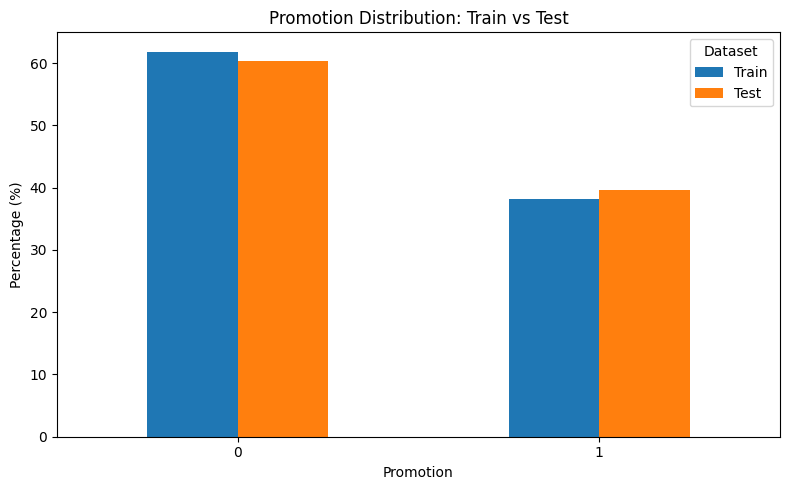

In [58]:
promo_percentage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Promotion Distribution: Train vs Test")
plt.xlabel("Promotion")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Dataset")

plt.tight_layout()
plt.show()